# Notebook 01 — EDA & Data Preparation

**Module:** ITI113 Machine Learning & Operations  
**Focus Area:** A — Data & EDA  
**Estimated Runtime:** 5–8 minutes on `ml.t3.medium`

---

## What this notebook does

1. Downloads the UCI Heart Disease (Cleveland) dataset and uploads it to S3
2. Exploratory Data Analysis — distributions, missing values, class balance
3. Feature engineering — `age_group`, `high_risk_count`
4. Train/test split (stratified 80/20) and StandardScaler
5. Saves four processed CSVs to S3 for Notebook 02 and the pipeline

## How to adapt this for your own project

- Replace the dataset loading cell with your own source
- Update `TARGET_COLUMN`, `NUMERIC_FEATURES`, `CATEGORICAL_FEATURES` in the config cell
- The S3 save logic at the end requires no changes

## Prerequisites

- SageMaker Studio, kernel **Python 3 (Data Science 3.0)**, instance `ml.t3.medium`
- SageMaker execution role has S3 read/write on the default bucket
- No extra package installs needed


In [1]:
# After running, restart the kernel before continuing.
%pip install --quiet --upgrade --force-reinstall "sagemaker>=2,<3" boto3 botocore

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
dash 2.18.1 requires dash-core-components==2.0.0, which is not installed.
dash 2.18.1 requires dash-html-components==2.0.0, which is not installed.
dash 2.18.1 requires dash-table==5.0.0, which is not installed.
skops 0.14.0 requires prettytable>=3.9, which is not installed.
aiobotocore 3.7.0 requires botocore<1.43.1,>=1.42.90, but you have botocore 1.43.55 which is incompatible.
amazon-sagemaker-sql-editor 0.2.5 requires rpds-py==0.27.1, but you have rpds-py 2026.6.3 which is incom

Note: you may need to restart the kernel to use updated packages.


## 0. Configuration

Edit the values in this cell. Everything else references these variables.

In [2]:
import sagemaker, boto3

session = sagemaker.Session()
role    = sagemaker.get_execution_role()
region  = boto3.Session().region_name

TEAM_ID = "team07" # "team01"
STUDENT_ID = "s703" # "s004"

BUCKET = "nyp-26s1-iti113"
PREFIX = f"iti113/{TEAM_ID}/data/heart-disease"

TARGET_COLUMN        = "target"
NUMERIC_FEATURES     = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL_FEATURES = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
RANDOM_STATE         = 42
TEST_SIZE            = 0.20

print(f"Bucket     : {BUCKET}")
print(f"Prefix     : {PREFIX}")
print(f"Region     : {region}")
print(f"Role       : {role.split('/')[-1]}")
print(f"Team ID    : {TEAM_ID}")
print(f"Student ID : {STUDENT_ID}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Bucket     : nyp-26s1-iti113
Prefix     : iti113/team07/data/heart-disease
Region     : ap-southeast-1
Role       : SageMakerExecutionRole-ITI113-Team07
Team ID    : team07
Student ID : s703


## 1. Load Dataset

We download the Cleveland Heart Disease dataset from the UCI ML Repository.
The dataset has 303 rows and 14 columns (13 features + 1 target).

| Column | Description |
|--------|-------------|
| age | Age in years |
| sex | 1=male, 0=female |
| cp | Chest pain type (0–3) |
| trestbps | Resting blood pressure (mmHg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar >120 mg/dl |
| restecg | Resting ECG results (0–2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1=yes) |
| oldpeak | ST depression (exercise vs rest) |
| slope | Slope of peak ST segment (0–2) |
| ca | Number of major vessels (0–3) |
| thal | Thalassemia (3=normal, 6=fixed, 7=reversible) |
| target | Heart disease present (1=yes, 0=no) |


In [3]:
import pandas as pd
import numpy as np
import io

COLUMNS = ['age','sex','cp','trestbps','chol','fbs',
           'restecg','thalach','exang','oldpeak','slope',
           'ca','thal','target']

url = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
       'heart-disease/processed.cleveland.data')

df_raw = pd.read_csv(url, names=COLUMNS, na_values='?')
df_raw['target'] = (df_raw['target'] > 0).astype(int)

print(f'Shape  : {df_raw.shape}')
print(f'Target : {df_raw[TARGET_COLUMN].value_counts().to_dict()}')
df_raw.head()


Shape  : (303, 14)
Target : {0: 164, 1: 139}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# Upload raw dataset to S3 for version control
s3 = boto3.client('s3')
buf = io.StringIO()
df_raw.to_csv(buf, index=False)
s3.put_object(Bucket=BUCKET, Key=f'{PREFIX}/raw/heart.csv', Body=buf.getvalue())
RAW_S3_URI = f's3://{BUCKET}/{PREFIX}/raw/heart.csv'
print(f'Raw data uploaded to: {RAW_S3_URI}')


Raw data uploaded to: s3://nyp-26s1-iti113/iti113/team07/data/heart-disease/raw/heart.csv


## 2. Exploratory Data Analysis

In [5]:
# 2.1 Missing values
missing = df_raw.isnull().sum()
print('Missing values:')
print(missing[missing > 0])
print(f'\nTotal missing: {missing.sum()}')
print('Strategy: impute ca and thal with mode (see Section 4)')


Missing values:
ca      4
thal    2
dtype: int64

Total missing: 6
Strategy: impute ca and thal with mode (see Section 4)


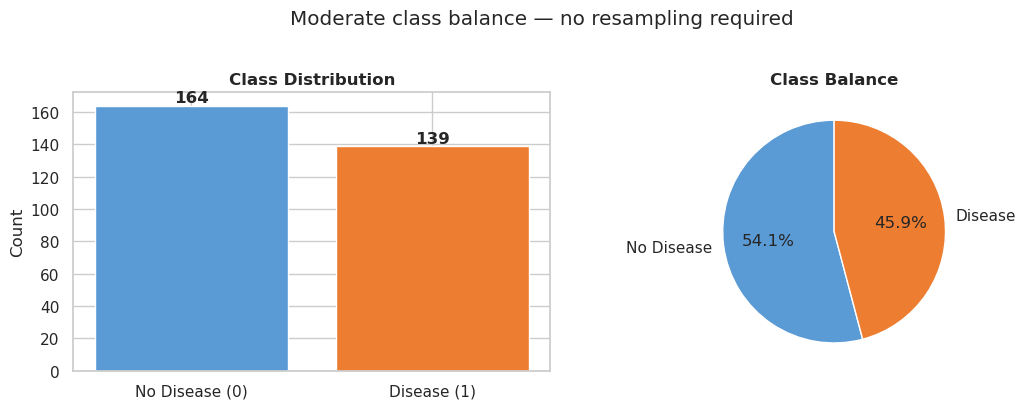

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# 2.2 Class distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df_raw[TARGET_COLUMN].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['#5B9BD5', '#ED7D31'])
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['No Disease', 'Disease'],
            autopct='%1.1f%%', colors=['#5B9BD5', '#ED7D31'], startangle=90)
axes[1].set_title('Class Balance', fontweight='bold')
plt.suptitle('Moderate class balance — no resampling required', y=1.02)
plt.tight_layout()
plt.show()


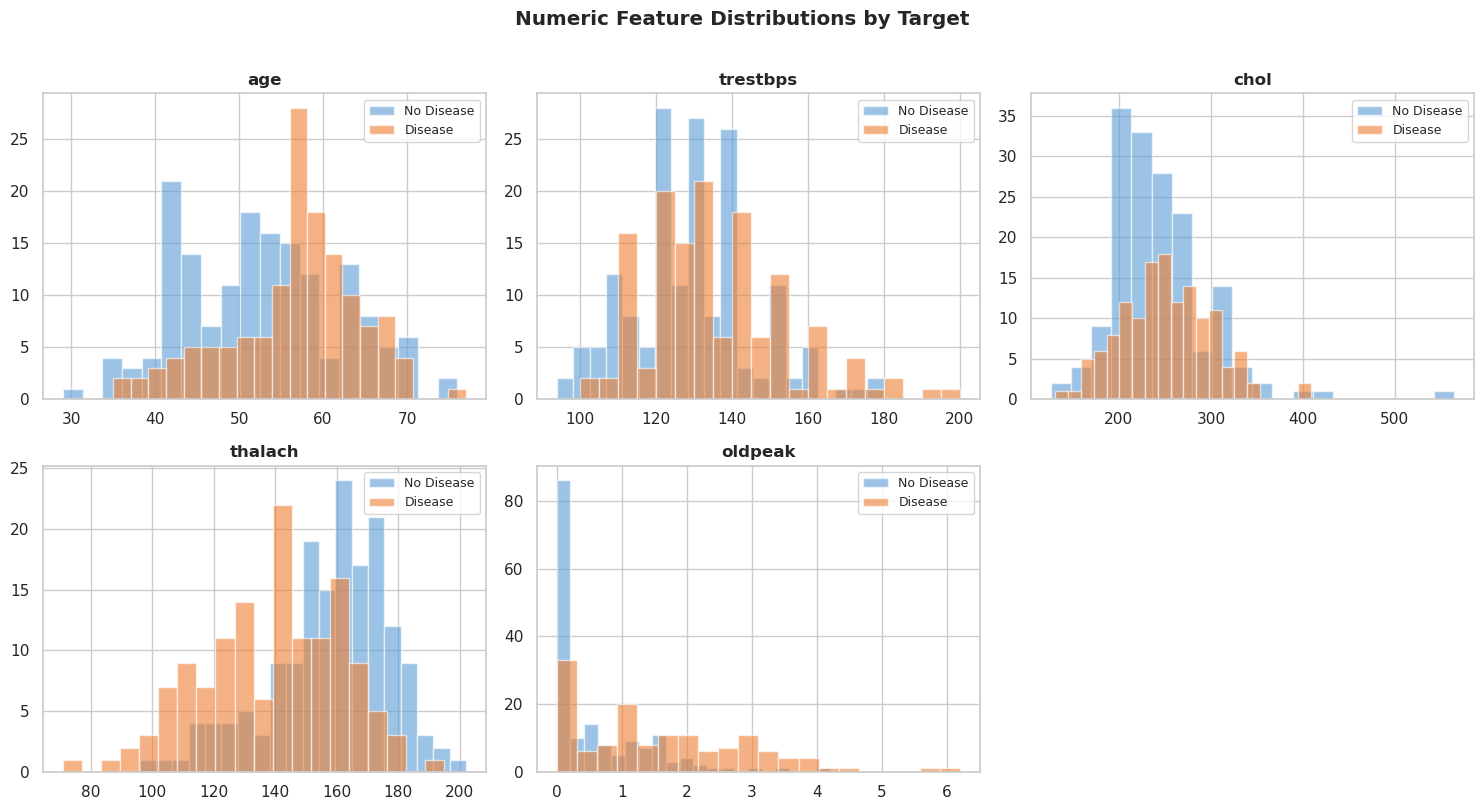

thalach: lower values -> higher risk  |  oldpeak: higher values -> higher risk


In [7]:
# 2.3 Numeric feature distributions split by target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_FEATURES):
    for tval, color, lbl in [(0,'#5B9BD5','No Disease'),(1,'#ED7D31','Disease')]:
        axes[i].hist(df_raw[df_raw[TARGET_COLUMN]==tval][col].dropna(),
                     bins=20, alpha=0.6, color=color, label=lbl, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=9)
axes[-1].set_visible(False)
plt.suptitle('Numeric Feature Distributions by Target', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('thalach: lower values -> higher risk  |  oldpeak: higher values -> higher risk')


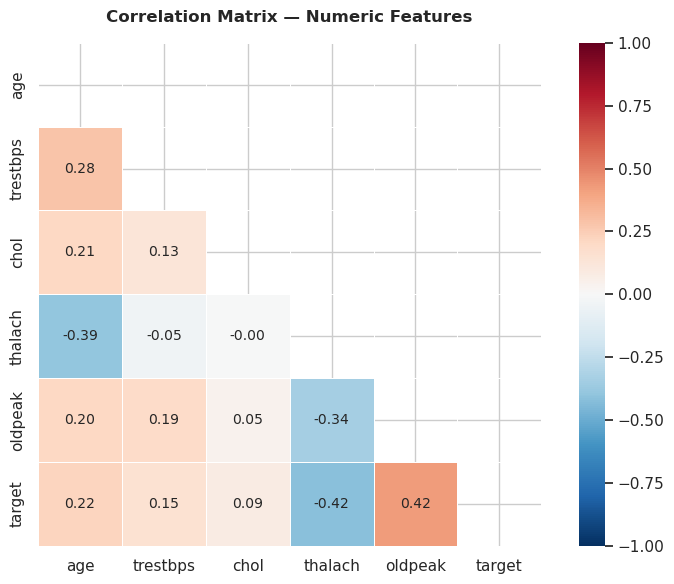

In [8]:
# 2.4 Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_raw[NUMERIC_FEATURES + [TARGET_COLUMN]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size':10})
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


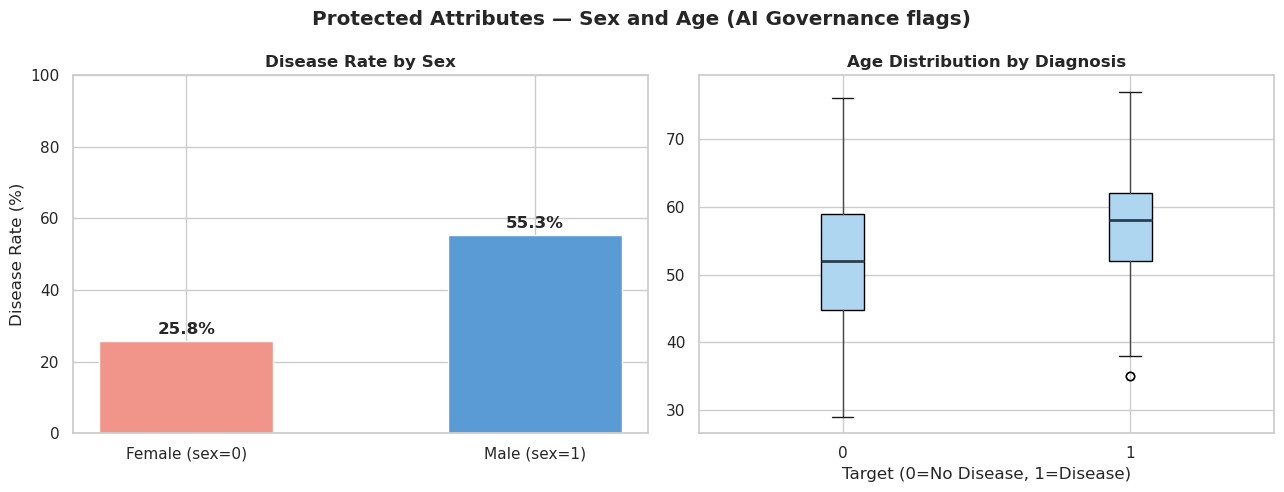

Female disease rate: 25.8%
Male   disease rate: 55.3%
Governance: formal disparate impact test in Notebook 04


In [9]:
# 2.5 Sex and age governance analysis
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Disease rate by sex
sex_rate = df_raw.groupby('sex')[TARGET_COLUMN].mean() * 100
bars = axes[0].bar(['Female (sex=0)', 'Male (sex=1)'], sex_rate.values,
                   color=['#F1948A', '#5B9BD5'], width=0.5)
axes[0].set_ylabel('Disease Rate (%)')
axes[0].set_ylim(0, 100)
axes[0].set_title('Disease Rate by Sex', fontweight='bold')
for bar, v in zip(bars, sex_rate.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+2, f'{v:.1f}%', ha='center', fontweight='bold')

# Age distribution by target
df_raw.boxplot(column='age', by=TARGET_COLUMN, ax=axes[1],
               patch_artist=True,
               boxprops=dict(facecolor='#AED6F1'),
               medianprops=dict(color='#2C3E50', linewidth=2))
axes[1].set_title('Age Distribution by Diagnosis', fontweight='bold')
axes[1].set_xlabel('Target (0=No Disease, 1=Disease)')
plt.suptitle('Protected Attributes — Sex and Age (AI Governance flags)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Female disease rate: {sex_rate[0]:.1f}%')
print(f'Male   disease rate: {sex_rate[1]:.1f}%')
print('Governance: formal disparate impact test in Notebook 04')


## 3. Feature Engineering & Preprocessing

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = df_raw.copy()

# Step 1: impute missing values with mode
for col in ['ca', 'thal']:
    mode_val = df[col].mode()[0]
    n = df[col].isnull().sum()
    df[col] = df[col].fillna(mode_val)
    print(f'Imputed {n} missing in "{col}" with mode={mode_val}')

# Step 2: feature engineering
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 45, 60, 100],
    labels=[0, 1, 2]
).astype(int)

df['high_risk_count'] = (
    (df['exang'] == 1).astype(int)
    + (df['fbs'] == 1).astype(int)
    + (df['ca'] > 0).astype(int)
)

print('\nEngineered features added: age_group, high_risk_count')
print(df[['age', 'age_group', 'exang', 'fbs', 'ca', 'high_risk_count']].head(5))


Imputed 4 missing in "ca" with mode=0.0
Imputed 2 missing in "thal" with mode=3.0

Engineered features added: age_group, high_risk_count
    age  age_group  exang  fbs   ca  high_risk_count
0  63.0          2    0.0  1.0  0.0                1
1  67.0          2    1.0  0.0  3.0                2
2  67.0          2    1.0  0.0  2.0                2
3  37.0          0    0.0  0.0  0.0                0
4  41.0          0    0.0  0.0  0.0                0


In [11]:
# Step 3: train/test split (stratified)
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES + ['age_group','high_risk_count']
X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print(f'Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows')
print(f'Train class balance: {y_train.mean():.3f}  (full dataset: {y.mean():.3f})')
print(f'Test  class balance: {y_test.mean():.3f}  (stratification confirmed)')


Train: 242 rows  |  Test: 61 rows
Train class balance: 0.459  (full dataset: 0.459)
Test  class balance: 0.459  (stratification confirmed)


In [12]:
# Step 4: scale numeric features
# IMPORTANT: fit scaler on TRAIN data only, then transform both splits
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test[NUMERIC_FEATURES]  = scaler.transform(X_test[NUMERIC_FEATURES])
print('Scaling complete. Fit on train only — no data leakage.')


Scaling complete. Fit on train only — no data leakage.


## 4. Save Processed Data to S3

In [13]:
def save_csv_to_s3(df_or_series, bucket, key):
    buf = io.StringIO()
    if isinstance(df_or_series, pd.Series):
        df_or_series.to_csv(buf, index=False, header=True)
    else:
        df_or_series.to_csv(buf, index=False)
    s3.put_object(Bucket=bucket, Key=key, Body=buf.getvalue())
    return f's3://{bucket}/{key}'

p = f'{PREFIX}/processed'
paths = {
    'train_features': save_csv_to_s3(X_train,                   BUCKET, f'{p}/train_features.csv'),
    'train_labels'  : save_csv_to_s3(y_train.rename('target'),  BUCKET, f'{p}/train_labels.csv'),
    'test_features' : save_csv_to_s3(X_test,                    BUCKET, f'{p}/test_features.csv'),
    'test_labels'   : save_csv_to_s3(y_test.rename('target'),   BUCKET, f'{p}/test_labels.csv'),
}
for name, uri in paths.items():
    print(f'{name:<20}: {uri}')

PROCESSED_PREFIX = f's3://{BUCKET}/{p}'
print(f'\nProcessed prefix: {PROCESSED_PREFIX}')
print('Next: open Notebook 02 to run baseline experiments with MLflow.')


train_features      : s3://nyp-26s1-iti113/iti113/team07/data/heart-disease/processed/train_features.csv
train_labels        : s3://nyp-26s1-iti113/iti113/team07/data/heart-disease/processed/train_labels.csv
test_features       : s3://nyp-26s1-iti113/iti113/team07/data/heart-disease/processed/test_features.csv
test_labels         : s3://nyp-26s1-iti113/iti113/team07/data/heart-disease/processed/test_labels.csv

Processed prefix: s3://nyp-26s1-iti113/iti113/team07/data/heart-disease/processed
Next: open Notebook 02 to run baseline experiments with MLflow.


---
## Checklist before Notebook 02

- [ ] Raw dataset uploaded to S3
- [ ] No missing values remaining after imputation
- [ ] `age_group` and `high_risk_count` features created
- [ ] Stratified 80/20 train/test split completed
- [ ] Scaler fit on training data only
- [ ] Four processed CSVs saved to S3
- [ ] EDA observations and governance flags documented
